In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, auc
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from  sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier

# 1. Explore Dataset

### load the data and keep it as "raw" in-case we mess something up


In [5]:
#allow for all columns to be displayed
pd.set_option('display.max_columns', None)
#resets this
#pd.reset_option(‘max_columns’)

In [6]:
data_raw = pd.read_csv("insurance_claims.csv")
data_raw.head()

,sex,dob,policy_start_dt,policy_end_dt,prod_code,policy_type,sum_insured,claim_dt,hospital_id,hos_zipcode,admit_dt,discharge_dt,payment_dt,claim_amt,nursing_chg,surgery_chg,cons_fee,test_chg,pharmacy_cost,other_chg,pre_hosp_exp,post_hosp_exp,other_chg_non_hosp,copayment,settle_amt,payment_type,hosp_type,recommendation,fraud,holdout,holdout_order
0,NaN,20-Oct-1949,1-Jul-2009,30-Jun-2010,O,C,5000,9-Aug-2010,NaN,UF7CS2,25-Jun-2010,27-Jun-2010,13-Aug-2010,1885.36000,157.110000,0.00,455.63000,1242.64,29.980000,0.00,0.00,0.00,0.0,0.0,1885,B,N,Genuine,0.0,0,0
1,F,9-Jan-1939,14-Feb-2007,4-Nov-2008,A,D,1500,5-Dec-2008,OLT-UWA470,ZD25KR16,4-Feb-2008,4-Mar-2008,19-May-2009,221.10001,24.969999,0.00,7.80000,133.41,45.330002,9.60,12.56,27.85,0.0,0.0,210,B,N,Genuine,0.0,0,0
2,M,8-Feb-1984,3-Jul-2009,2-Jun-2010,A,D,20000,18-Dec-2009,YGV-YGC685,ZD25KR16,30-Jun-2009,30-Jun-2009,19-Dec-2009,1771.39000,0.000000,1771.39,0.00000,0.00,0.000000,0.00,0.00,0.00,0.0,0.0,1770,B,N,Genuine,0.0,0,0
3,F,16-Nov-1957,26-Apr-2009,25-Apr-2010,A,H,5000,19-Jan-2010,YGV-YGC685,MA1PS37,29-Apr-2010,30-Aug-2010,30-Sep-2010,3050.63990,0.000000,0.00,0.00000,0.00,0.000000,0.00,0.00,0.00,0.0,0.0,2725,A,Y,Genuine,0.0,0,0
4,F,7-Feb-1998,7-Jan-2010,6-Jan-2011,A,A,30000,6-Aug-2010,KAP-PIA435,WV13VS62,16-Jul-2010,18-Jul-2010,15-Aug-2010,2509.90990,1099.120000,0.00,317.51999,764.50,193.450000,135.31,0.00,0.00,0.0,0.0,2080,B,N,Genuine,0.0,0,0


In [7]:
#super hacky not nice but should not matter with only 10 counts
data_raw["hosp_type"][data_raw["hosp_type"]=="."] = "N"

C:\Users\Nutzer\anaconda3\envs\master thesis\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


### Split Data Set into the actuall training/testing data and the holdout set for predictions

In [8]:
data_full_train = data_raw.loc[data_raw["holdout"]==0]
data_holdout = data_raw.loc[data_raw["holdout"]==1]

### Remove holdout and holdout_order column from the full_train data

In [9]:
data_full_train = data_full_train.drop(columns=["holdout", "holdout_order"])

### Before going into the feature engingeering we check for the NA density in each column

In [10]:
data_full_train.isnull().sum()

sex                    4436
dob                       0
policy_start_dt           0
policy_end_dt             0
prod_code                 0
policy_type               0
sum_insured               0
claim_dt                  0
hospital_id           17216
hos_zipcode               0
admit_dt                  0
discharge_dt              0
payment_dt                0
claim_amt                 0
nursing_chg               0
surgery_chg               0
cons_fee                  0
test_chg                  0
pharmacy_cost             0
other_chg                 0
pre_hosp_exp              0
post_hosp_exp             0
other_chg_non_hosp        0
copayment                 0
settle_amt                0
payment_type              0
hosp_type                 0
recommendation            0
fraud                     0
dtype: int64

This is actually not too bad. Barely any missing data. For the Sex we have 4.4% of the data having no Gender I will just assing the gender by randomly drawing from the underlying distribution of males/females
On the other hand we have the hospital_id. With ~20% missing we could either just drop all rows (not an option in this use-casse), drop the whole column - which I would rather not since is suspect this feature to be important - or try to somehow fill in the values. Since we actually do know the zipcode of each hospital they way I will try to fill the missing values is by looking for other hospitals in the same zip area and fill it from there. 

### Lets Check the balance of the full data

In [11]:
sns.countplot(x=data_full_train["fraud"])
ratio=sum(data_full_train["fraud"]== 1) / len(data_full_train["fraud"])
print(f"class 1 share: {ratio}")
print(f"class 0 share: {1-ratio}")

class 1 share: 0.217
class 0 share: 0.783
Error in callback <function flush_figures at 0x1136DE88> (for post_execute):


KeyboardInterrupt: 

Data is heavily unbalanced with almost 80/20. We need to keep this in mind.

### Before doing anything we split our data in a train/test set - I will also split the test set again for a train/validation/test split.

In [12]:
data_train, data_test = train_test_split(data_full_train, train_size = 0.8, shuffle=True, stratify=data_full_train["fraud"], random_state=242)
data_validation, data_test = train_test_split(data_test, train_size = 0.6, shuffle=True, stratify=data_test["fraud"], random_state=242)
print(f"train shape: {data_train.shape}")
print(f"validation shape: {data_validation.shape}")
print(f"test shape: {data_test.shape}")

train shape: (64000, 29)
validation shape: (9600, 29)
test shape: (6400, 29)


## 1.1 Data Wrangling

### Impute and Encode Sex

In [13]:
##couple of helper-functions to transform the data



def impute_distribution(data, weights=None, classes=None):
    
    if weights is None and classes is None:
        
        weights = []
        classes = data.unique()
        N_not_nan = len(data) - data.isna().sum()
        
        for key, class_ in enumerate(classes):
            weights.append(sum(data == class_) / N_not_nan)
            
        na_fills = np.random.choice(a=classes, size=data.isna().sum(), replace=True, p=weights)
        temp = data.copy()
        temp[temp.isna()] = na_fills
        return temp, weights, classes
    
    else:
        na_fills = np.random.choice(a=classes, size=data.isna().sum(), replace=True, p=weights)
        temp = data.copy()
        temp[temp.isna()] = na_fills
        return temp

    
def transform_binary_category(data):
    temp = data.copy()
    classes = np.sort(data.unique())
    
    temp[temp==classes[0]] = 0
    temp[temp==classes[1]] = 1
    
    print(f"class 0: {classes[0]}")
    print(f"class 1: {classes[1]}")
    
    return temp

    

In [14]:
data_train["sex"], sex_weights, sex_classes = impute_distribution(data_train["sex"])
data_validation["sex"] = impute_distribution(data_validation["sex"], sex_weights, sex_classes)
data_test["sex"] = impute_distribution(data_test["sex"], sex_weights, sex_classes)

<AxesSubplot:xlabel='sex', ylabel='count'>

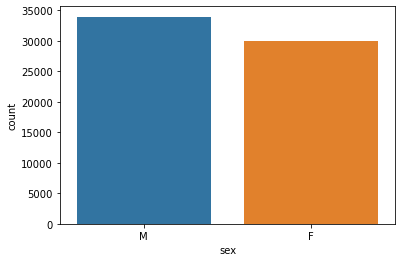

In [15]:
sns.countplot(x=data_train["sex"])

In [16]:
data_train["sex"] = transform_binary_category(data_train["sex"])
data_validation["sex"] = transform_binary_category(data_validation["sex"])
data_test["sex"] = transform_binary_category(data_test["sex"])

class 0: F
class 1: M
class 0: F
class 1: M
class 0: F
class 1: M


### Inpute HospitalID and change the format

I will use the approach of filling the NA values by a random replacement (meaning other hospital) in the same zip code. This could be improved by actually trying to predict the hospital by another model but I suspect this "simple" method will suffice. 

In [17]:
def fill_from_same_category(data):
    
    temp = data.copy()
    
    hos_in_zip = []
    unique_zip = data["hos_zipcode"][data["hospital_id"].isna()].unique()
    
    
    for _, zip_ in enumerate(unique_zip):
        looper = data["hospital_id"][data["hos_zipcode"]==zip_].unique()
        looper = [x for x in looper if x != pd.isnull(x)]
        #print(looper)
        hos_in_zip.append(temp)
        
        
    

In [18]:
print("number of different zip-codes: " + str(len(data_train["hos_zipcode"].unique())))

number of different zip-codes: 2470


In [19]:
print("number of different zip-codes with NA hospital: " +
      str(len(data_train["hos_zipcode"][data_train["hospital_id"].isna()].unique())))

number of different zip-codes with NA hospital: 1543


In [20]:
fill_from_same_category(data_train)

In [21]:
data_train[["hospital_id", "hos_zipcode"]][data_train["hospital_id"].isna()]

,hospital_id,hos_zipcode
44937,NaN,IC17KV65
79475,NaN,SM34YU28
318,NaN,ZD25KR16
68172,NaN,EM3IY71
71284,NaN,DH5KM55
...,...,...
69256,NaN,ZD25KR16
2532,NaN,IT30MD76
34907,NaN,HU15EY39
53466,NaN,ZD25KR16


Okay filling the name with this schema will not work. since hospital id and zipcode will be highly correlated I will drop the column for now. I would have perfered to keep id and drop zip since we have more information this way but any other solution to this problem will be more tedious. 

In [22]:
data_train = data_train.drop(columns=["hospital_id"])
data_test = data_test.drop(columns=["hospital_id"])
data_validation = data_validation.drop(columns=["hospital_id"])

In [23]:
data_train

,sex,dob,policy_start_dt,policy_end_dt,prod_code,policy_type,sum_insured,claim_dt,hos_zipcode,admit_dt,discharge_dt,payment_dt,claim_amt,nursing_chg,surgery_chg,cons_fee,test_chg,pharmacy_cost,other_chg,pre_hosp_exp,post_hosp_exp,other_chg_non_hosp,copayment,settle_amt,payment_type,hosp_type,recommendation,fraud
40305,1,11-Jul-1986,30-Oct-2009,29-Oct-2010,A,D,10000,10-Aug-2010,XS1QT42,17-Aug-2010,19-Aug-2010,17-Aug-2010,1458.300000,297.69000,0.00,196.47000,424.950010,203.170000,187.620000,0.0000,0.0,504.95999,0.0,1305,F,Y,Genuine,0.0
44937,0,4-Feb-1970,6-Dec-2009,5-Dec-2010,B,D,7500,4-Mar-2010,IC17KV65,4-Mar-2010,9-Mar-2010,9-Apr-2010,431.230010,0.00000,0.00,431.23001,0.000000,0.000000,0.000000,0.0000,0.0,0.00000,0.0,430,A,Y,Genuine,0.0
66953,0,4-Nov-1955,29-Dec-2009,28-Dec-2010,A,A,5000,18-Mar-2010,GM24XW24,25-Mar-2010,25-Mar-2010,30-Mar-2010,1711.260000,59.07000,0.00,26.25000,0.000000,6.560000,1612.810100,1612.8101,0.0,17.77000,0.0,1700,B,N,Genuine,0.0
40268,0,24-Jan-1926,4-Dec-2007,28-Feb-2009,A,D,0,29-Jul-2008,TB33RX68,28-Jul-2008,2-Sep-2008,21-Aug-2008,1930.160000,175.05000,1250.33,150.03999,4.500000,327.739990,22.510000,0.0000,0.0,0.00000,0.0,1910,A,Y,Genuine,0.0
79475,1,26-Feb-2005,4-Mar-2010,3-Mar-2011,A,B,10000,13-Jul-2010,SM34YU28,26-Apr-2010,28-Apr-2010,17-Jul-2010,946.700010,0.00000,0.00,0.00000,0.000000,0.000000,0.000000,0.0000,0.0,0.00000,0.0,945,F,Y,Genuine,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34253,0,26-Jan-2006,18-Jan-2008,16-Jan-2009,A,D,750,1-Aug-2009,LD32MW46,12-Sep-2008,12-Nov-2008,10-Nov-2009,94.470001,0.00000,0.00,15.61000,10.680000,41.900002,26.290001,0.0000,0.0,0.00000,0.0,85,B,N,Discuss,0.0
542,1,13-Aug-1975,20-Jun-2007,19-Jun-2008,A,B,5000,25-Apr-2008,ME2NE6,24-Apr-2008,26-Apr-2008,4-Oct-2008,459.799990,165.63000,0.00,113.87000,60.459999,119.840000,0.000000,0.0000,0.0,0.00000,0.0,455,A,Y,Genuine,1.0
27244,1,15-Feb-1968,4-Feb-2008,2-Feb-2009,A,D,750,31-Mar-2009,ZD25KR16,16-Jan-2009,16-Jan-2009,26-May-2009,701.630000,0.00000,0.00,701.63000,0.000000,0.000000,0.000000,0.0000,0.0,0.00000,0.0,390,B,N,Investigate,0.0
40790,1,6-Jan-1974,3-Feb-2008,2-Feb-2009,A,B,10000,19-Nov-2008,RU15KS20,22-Oct-2008,25-Oct-2008,28-Nov-2008,908.330020,340.48999,0.00,102.86000,227.880000,210.500000,26.600000,0.0000,0.0,0.00000,0.0,790,A,Y,Genuine,1.0


### Manage Date Types: dob, policy_start_dt, policy_end_dt, claim_dt, admit_dt

To manage the date types I wil go from absolute dates to date differences with the claim date as reference i.e 
- dob -> age at claim
- policy_start -> policy duration at claim
- policy_end -> time till end 
- claim_dt -> maybe change into Quarters? 
- admit_dt -> time between claim and admit


In [24]:
def time_diff(col1, col2, time="Y"):
    '''
    Helperfunction to calculate the time difference between two columns of a pandas DF.
    Diff will be calculated using col2 as the more recent time. the time argument will determine the output format.
    Default time="Y" - years.
    '''
    temp_1 = pd.to_datetime(col1, format="%d-%b-%Y", errors='coerce')
    temp_2 = pd.to_datetime(col2, format="%d-%b-%Y", errors='coerce')
    
    diff = (temp_2 - temp_1) /np.timedelta64(1, time)
    
    if any(pd.isna(diff)):
        diff[pd.isna(diff)] = np.nanmean(diff)
    return diff

In [25]:
data_train["dob"] = time_diff(data_train["dob"], data_train["claim_dt"])
data_test["dob"] = time_diff(data_test["dob"], data_test["claim_dt"])
data_validation["dob"] = time_diff(data_validation["dob"], data_validation["claim_dt"])

data_train.rename(columns = {"dob":"age_at_claim"}, inplace = True)
data_test.rename(columns = {"dob":"age_at_claim"}, inplace = True)
data_validation.rename(columns = {"dob":"age_at_claim"}, inplace = True)

In [26]:
data_train["policy_start_dt"] = time_diff(data_train["policy_start_dt"], data_train["claim_dt"])
data_test["policy_start_dt"] = time_diff(data_test["policy_start_dt"], data_test["claim_dt"])
data_validation["policy_start_dt"] = time_diff(data_validation["policy_start_dt"], data_validation["claim_dt"])

data_train.rename(columns = {"policy_start_dt":"years_since_policy_start"}, inplace = True)
data_test.rename(columns = {"policy_start_dt":"years_since_policy_start"}, inplace = True)
data_validation.rename(columns = {"policy_start_dt":"years_since_policy_start"}, inplace = True)

In [27]:
data_train["policy_end_dt"] = time_diff(data_train["claim_dt"], data_train["policy_end_dt"])
data_test["policy_end_dt"] = time_diff(data_test["claim_dt"], data_test["policy_end_dt"])
data_validation["policy_end_dt"] = time_diff(data_validation["claim_dt"], data_validation["policy_end_dt"])

data_train.rename(columns = {"policy_end_dt":"years_till_policy_end"}, inplace = True)
data_test.rename(columns = {"policy_end_dt":"years_till_policy_end"}, inplace = True)
data_validation.rename(columns = {"policy_end_dt":"years_till_policy_end"}, inplace = True)

In [28]:
data_train["payment_dt"] = time_diff(data_train["claim_dt"], data_train["payment_dt"], "D")
data_test["payment_dt"] = time_diff(data_test["claim_dt"], data_test["payment_dt"], "D")
data_validation["payment_dt"] = time_diff(data_validation["claim_dt"], data_validation["payment_dt"], "D")

data_train.rename(columns = {"payment_dt":"days_till_pay"}, inplace = True)
data_test.rename(columns = {"payment_dt":"days_till_pay"}, inplace = True)
data_validation.rename(columns = {"payment_dt":"days_till_pay"}, inplace = True)

##no point keeping this date
data_train = data_train.drop(columns=["claim_dt"])
data_test = data_test.drop(columns=["claim_dt"])
data_validation = data_validation.drop(columns=["claim_dt"])

In [29]:
data_train["admit_dt"] = time_diff(data_train["admit_dt"], data_train["discharge_dt"], "D")
data_test["admit_dt"] = time_diff(data_test["admit_dt"], data_test["discharge_dt"], "D")
data_validation["admit_dt"] = time_diff(data_validation["admit_dt"], data_validation["discharge_dt"], "D")

data_train.rename(columns = {"admit_dt":"days_in_hosp"}, inplace = True)
data_test.rename(columns = {"admit_dt":"days_in_hosp"}, inplace = True)
data_validation.rename(columns = {"admit_dt":"days_in_hosp"}, inplace = True)

##no point keeping this date
data_train = data_train.drop(columns=["discharge_dt"])
data_test = data_test.drop(columns=["discharge_dt"])
data_validation = data_validation.drop(columns=["discharge_dt"])

### Encode Categorical Features prod_code, policy_type, payment_type, hosp_type, recommendation

In [30]:
prod_code_train = pd.get_dummies(data_train["prod_code"], prefix="prod_code")
prod_code_test = pd.get_dummies(data_test["prod_code"], prefix="prod_code")
prod_code_val = pd.get_dummies(data_validation["prod_code"], prefix="prod_code")

prod_code_train = prod_code_train.drop(columns=["prod_code_E"])
#prod_code_test = data_test.drop(columns=["prod_code_E"])
#prod_code_val = data_validation.drop(columns=["prod_code_E"])

data_train = pd.concat([data_train, prod_code_train], axis=1)
data_test = pd.concat([data_test, prod_code_test], axis=1)
data_validation = pd.concat([data_validation, prod_code_val], axis=1)


data_train = data_train.drop(columns=["prod_code"])
data_test = data_test.drop(columns=["prod_code"])
data_validation = data_validation.drop(columns=["prod_code"])

In [31]:
policy_type_train = pd.get_dummies(data_train["policy_type"], prefix="policy_type")
policy_type_test = pd.get_dummies(data_test["policy_type"], prefix="policy_type")
policy_type_val = pd.get_dummies(data_validation["policy_type"], prefix="policy_type")

policy_type_train = policy_type_train.drop(columns=["policy_type_E"])
policy_type_test = policy_type_test.drop(columns=["policy_type_E"])
policy_type_val = policy_type_val.drop(columns=["policy_type_E"])

data_train = pd.concat([data_train, policy_type_train], axis=1)
data_test = pd.concat([data_test, policy_type_test], axis=1)
data_validation = pd.concat([data_validation, policy_type_val], axis=1)


data_train = data_train.drop(columns=["policy_type"])
data_test = data_test.drop(columns=["policy_type"])
data_validation = data_validation.drop(columns=["policy_type"])

In [32]:
payment_type_train = pd.get_dummies(data_train["payment_type"], prefix="payment_type")
payment_type_test = pd.get_dummies(data_test["payment_type"], prefix="payment_type")
payment_type_val = pd.get_dummies(data_validation["payment_type"], prefix="payment_type")

payment_type_train = payment_type_train.drop(columns=["payment_type_D"])
#payment_type_test = payment_type_test.drop(columns=["policy_type_E"])
#payment_type_val = payment_type_val.drop(columns=["policy_type_E"])

data_train = pd.concat([data_train, payment_type_train], axis=1)
data_test = pd.concat([data_test, payment_type_test], axis=1)
data_validation = pd.concat([data_validation, payment_type_val], axis=1)


data_train = data_train.drop(columns=["payment_type"])
data_test = data_test.drop(columns=["payment_type"])
data_validation = data_validation.drop(columns=["payment_type"])

In [33]:
data_train.hosp_type = transform_binary_category(data_train.hosp_type)
data_test.hosp_type = transform_binary_category(data_test.hosp_type)
data_validation.hosp_type = transform_binary_category(data_validation.hosp_type)

class 0: N
class 1: Y
class 0: N
class 1: Y
class 0: N
class 1: Y


In [34]:
data_train.recommendation[data_train.recommendation=="Genuine"] = 0
data_train.recommendation[data_train.recommendation=="Discuss"] = 1
data_train.recommendation[data_train.recommendation=="Investigate"] = 2

data_test.recommendation[data_test.recommendation=="Genuine"] = 0
data_test.recommendation[data_test.recommendation=="Discuss"] = 1
data_test.recommendation[data_test.recommendation=="Investigate"] = 2

data_validation.recommendation[data_validation.recommendation=="Genuine"] = 0
data_validation.recommendation[data_validation.recommendation=="Discuss"] = 1
data_validation.recommendation[data_validation.recommendation=="Investigate"] = 2

C:\Users\Nutzer\anaconda3\envs\master thesis\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
C:\Users\Nutzer\anaconda3\envs\master thesis\lib\site-packages\ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
C:\Users\Nutzer\anaconda3\envs\master thesis\lib\site-packages\ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-vers

### Back to the zip_code which is a categorical feature with over 2000 different values

In [35]:
len(data_train.hos_zipcode.unique())

2470

In [ ]:
sns.histplot(x=data_train.hos_zipcode, stat="density")
plt.ylim(0, 0.007)

(0.0, 0.007)

In [ ]:
data_train.head()

First idea is obviously one-hot-encoding, with a category cardenality of 2400+ this would create way too many coloumns and will affect performance. Grouping them together appears to be not an option aswell since even the highest frequency class only makes up for 0.7% of the data. The method I will try for now is to calculate the average cost per day grouped by each hospital(zip). This will result in an "semi" ordinal feature which should Identify each hospital_zip uniquely. 

In [ ]:
def average_cost_by_group(data, cost_dict=None):
    if cost_dict is None:
        unique_zips = data.hos_zipcode.unique()
        cost_zip_dict = dict()



        for key, zip_ in enumerate(unique_zips):
            n_policy = len(data.hos_zipcode.loc[data.hos_zipcode==zip_])
            n_days = sum(data.days_in_hosp.loc[data.hos_zipcode==zip_])
            if n_days == 0:
                n_days = 1
            sum_money = sum(data.claim_amt.loc[data.hos_zipcode==zip_])

            temp = sum_money / (n_policy * n_days)

            data.hos_zipcode.loc[data.hos_zipcode==zip_] = temp
            cost_zip_dict[zip_] = temp
        
        return data, cost_zip_dict
    
    else:
        unique_zips = data.hos_zipcode.unique()
        mean_fills = np.mean(list(cost_dict.values()))
        for key, zip_ in enumerate(unique_zips):
            try:
                data.hos_zipcode.loc[data.hos_zipcode==zip_] = cost_dict[zip_]
            except(KeyError):
                data.hos_zipcode.loc[data.hos_zipcode==zip_] = mean_fills
                print("zip_error")
        return data
            

In [ ]:
data_train, train_dict = average_cost_by_group(data_train.copy())
data_test = average_cost_by_group(data_test.copy(), train_dict)
data_validation = average_cost_by_group(data_validation.copy(), train_dict)

### Lastly: Numerical features

We do have plenty of numerical features, each of them on a different scale. We now want to tune these down so there arent too many jumps in orders of magnitude between those.

-- skip for now since we are using XGBoost with trees as base models - which are not sensitive towards the scale

### Store files as csv to be used in other enviroments -> pycharm due to memory errors

In [ ]:
data_train.to_csv("data_train.csv")
data_test.to_csv("data_test.csv")
data_validation.to_csv("data_validation.csv")

# 2. Understanding of the Data

## to increase the performance of our model we need to understand better how these features are correlated and connected with the target

In [3]:
data_train = pd.read_csv("data_train.csv", index_col=0)
data_test = pd.read_csv("data_test.csv", index_col=0)
data_validation = pd.read_csv("data_validation.csv",index_col=0)

In [4]:
data_train.head()

,sex,age_at_claim,years_till_policy_end,sum_insured,hos_zipcode,days_in_hosp,days_till_pay,surgery_chg,cons_fee,test_chg,...,other_chg_non_hosp,copayment,settle_amt,hosp_type,recommendation,fraud,prod_code_A,policy_type_B,payment_type_A,payment_type_Rem
40305,1,24.082630,0.219033,10000,0.679668,2.0,7.0,0.00,196.47000,424.95001,...,504.95999,0.0,1305,1,0,0.0,1,0,0,1
44937,0,40.077483,0.755662,7500,58.539890,5.0,36.0,0.00,431.23001,0.00000,...,0.00000,0.0,430,1,0,0.0,0,0,1,0
66953,0,54.369357,0.780303,5000,13.631011,0.0,12.0,0.00,26.25000,0.00000,...,17.77000,0.0,1700,0,0,0.0,1,0,0,0
40268,0,82.512303,0.585912,0,1.557638,36.0,23.0,1250.33,150.03999,4.50000,...,0.00000,0.0,1910,1,0,0.0,1,0,1,0
79475,1,5.374511,0.637932,10000,7.576993,2.0,4.0,0.00,0.00000,0.00000,...,0.00000,0.0,945,1,0,1.0,1,1,0,1


In [5]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 64000 entries, 40305 to 30425
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sex                    64000 non-null  int64  
 1   age_at_claim           64000 non-null  float64
 2   years_till_policy_end  64000 non-null  float64
 3   sum_insured            64000 non-null  int64  
 4   hos_zipcode            64000 non-null  float64
 5   days_in_hosp           64000 non-null  float64
 6   days_till_pay          64000 non-null  float64
 7   surgery_chg            64000 non-null  float64
 8   cons_fee               64000 non-null  float64
 9   test_chg               64000 non-null  float64
 10  pharmacy_cost          64000 non-null  float64
 11  other_chg              64000 non-null  float64
 12  pre_hosp_exp           64000 non-null  float64
 13  post_hosp_exp          64000 non-null  float64
 14  other_chg_non_hosp     64000 non-null  float64
 15

In [6]:
data_train.describe()

,sex,age_at_claim,years_till_policy_end,sum_insured,hos_zipcode,days_in_hosp,days_till_pay,surgery_chg,cons_fee,test_chg,...,other_chg_non_hosp,copayment,settle_amt,hosp_type,recommendation,fraud,prod_code_A,policy_type_B,payment_type_A,payment_type_Rem
count,64000.000000,64000.000000,64000.000000,6.400000e+04,6.400000e+04,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,...,64000.000000,64000.000000,6.400000e+04,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,0.531125,37.483982,0.388314,7.884447e+04,1.138150e+02,23.443016,72.740641,204.065640,274.390404,174.842085,...,50.710079,17.235030,3.969622e+03,0.506328,0.096703,0.217000,0.926828,0.154719,0.328437,0.108391
std,0.499034,19.773581,0.433609,4.538469e+06,1.062324e+04,43.314582,94.617912,1289.007613,6669.231795,3961.507508,...,1745.994686,243.213901,6.912758e+04,0.499964,0.342523,0.412206,0.260420,0.361639,0.469649,0.310876
min,0.000000,-2.006886,-5.349870,0.000000e+00,2.667185e-03,-1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,24.860196,0.114992,2.500000e+03,2.904062e-02,2.000000,15.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,4.200000e+02,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,1.000000,36.340240,0.407948,5.000000e+03,8.214272e-01,4.000000,39.000000,0.000000,12.100000,0.000000,...,0.000000,0.000000,8.950000e+02,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,53.460372,0.679001,1.000000e+04,2.730765e+00,28.000000,95.000000,0.000000,156.785000,95.129997,...,0.000000,0.000000,1.720000e+03,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,1.000000,108.620985,2.754334,1.129914e+09,2.339862e+06,568.000000,2017.000000,119771.960000,951012.440000,683976.560000,...,268130.530000,29522.480000,1.224824e+07,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000


by looking at the one-hot encoded features we can clearly see that only a couple of features make up for a majority of the cases so we should combine them. 

In [7]:
temp_prod_code_train = data_train.prod_code_C + data_train.prod_code_D + data_train.prod_code_F + data_train.prod_code_G + data_train.prod_code_O
temp_prod_code_test = data_test.prod_code_C + data_test.prod_code_D + data_test.prod_code_F + data_test.prod_code_G + data_test.prod_code_O
temp_prod_code_val = data_validation.prod_code_C + data_validation.prod_code_D + data_validation.prod_code_F + data_validation.prod_code_G + data_validation.prod_code_O

AttributeError: 'DataFrame' object has no attribute 'prod_code_C'

In [ ]:
data_train.drop(columns=["prod_code_C", "prod_code_D","prod_code_F","prod_code_G","prod_code_O"], inplace=True)
data_test.drop(columns=["prod_code_C", "prod_code_D","prod_code_F","prod_code_G","prod_code_O"], inplace=True)
data_validation.drop(columns=["prod_code_C", "prod_code_D","prod_code_F","prod_code_G","prod_code_O"], inplace=True)

In [ ]:
data_train["prod_code_Rem"] = temp_prod_code_train
data_test["prod_code_Rem"] = temp_prod_code_test
data_validation["prod_code_Rem"] = temp_prod_code_val

In [ ]:
temp_policy_type_train = data_train.policy_type_C + data_train.policy_type_F + data_train.policy_type_G + data_train.policy_type_H + data_train.policy_type_O
temp_policy_type_test = data_test.policy_type_C + data_test.policy_type_F + data_test.policy_type_G + data_test.policy_type_H + data_test.policy_type_O 
temp_policy_type_val = data_validation.policy_type_C + data_validation.policy_type_F + data_validation.policy_type_G + data_validation.policy_type_H + data_validation.policy_type_O 

In [ ]:
data_train.drop(columns=["policy_type_C", "policy_type_F", "policy_type_G", "policy_type_H","policy_type_O"], inplace=True)
data_test.drop(columns=["policy_type_C", "policy_type_F", "policy_type_G", "policy_type_H","policy_type_O"], inplace=True)
data_validation.drop(columns=["policy_type_C", "policy_type_F", "policy_type_G", "policy_type_H","policy_type_O"], inplace=True)

In [ ]:
data_train["policy_type_Rem"] = temp_policy_type_train
data_test["policy_type_Rem"] = temp_policy_type_test
data_validation["policy_type_Rem"] = temp_policy_type_val

In [ ]:
temp_payment_type_train = data_train.payment_type_C + data_train.payment_type_E + data_train.payment_type_F
temp_payment_type_test = data_test.payment_type_C + data_test.payment_type_E + data_test.payment_type_F
temp_payment_type_val = data_validation.payment_type_C + data_validation.payment_type_E + data_validation.payment_type_F

In [ ]:
data_train.drop(columns=["payment_type_C", "payment_type_E", "payment_type_F"], inplace=True)
data_test.drop(columns=["payment_type_C", "payment_type_E", "payment_type_F"], inplace=True)
data_validation.drop(columns=["payment_type_C", "payment_type_E", "payment_type_F"], inplace=True)

In [ ]:
data_train["payment_type_Rem"] = temp_payment_type_train
data_test["payment_type_Rem"] = temp_payment_type_test
data_validation["payment_type_Rem"] = temp_payment_type_val

In [ ]:
data_train.describe()

now we can go thru the relationship of each feature towards the target 

#### sex

In [9]:
pd.crosstab(index=data_train['sex'],columns=data_train['fraud'])

fraud,0.0,1.0
sex,,
0,23603,6405
1,26509,7483


In [10]:
print("p-value: "+str(stats.chi2_contingency(pd.crosstab(index=data_train['sex'],columns=data_train['fraud']))[1]))

p-value: 0.041203636894741734


apparently there is no real indicator that the sex is an indicator of fraud. 

#### age at claim

In [11]:
stats.pointbiserialr(data_train.fraud, data_train.age_at_claim)

PointbiserialrResult(correlation=0.004808684851902444, pvalue=0.22379641195134561)

barely any correlation with high p-value -> not relevant

#### years since policy start

In [12]:
stats.pointbiserialr(data_train.fraud, data_train.years_since_policy_start)

AttributeError: 'DataFrame' object has no attribute 'years_since_policy_start'

#### years since policy end

In [13]:
stats.pointbiserialr(data_train.fraud, data_train.years_till_policy_end)

PointbiserialrResult(correlation=0.0007688269704229857, pvalue=0.845787701014551)

#### sum insured

In [14]:
stats.pointbiserialr(data_train.fraud, data_train.sum_insured)

PointbiserialrResult(correlation=-0.002407123399706546, pvalue=0.542558646546352)

#### days in hosp

In [15]:
stats.pointbiserialr(data_train.fraud, data_train.days_in_hosp)

PointbiserialrResult(correlation=0.0021698262677875796, pvalue=0.5830621533461248)

#### days till pay

In [16]:
stats.pointbiserialr(data_train.fraud, data_train.days_till_pay)

PointbiserialrResult(correlation=0.014433352040440627, pvalue=0.00026071289159264755)

really low positive correlation but statistically significant

#### claim amt

In [ ]:
stats.pointbiserialr(data_train.fraud, data_train.claim_amt)

#### nursing chg

In [ ]:
stats.pointbiserialr(data_train.fraud, data_train.nursing_chg)

#### surgery chg

In [ ]:
stats.pointbiserialr(data_train.fraud, data_train.surgery_chg)

#### cons fee

In [ ]:
stats.pointbiserialr(data_train.fraud, data_train.cons_fee)

#### test chg

In [ ]:
stats.pointbiserialr(data_train.fraud, data_train.test_chg)

#### pharmacy cost

In [ ]:
stats.pointbiserialr(data_train.fraud, data_train.pharmacy_cost)

#### other chg

In [ ]:
stats.pointbiserialr(data_train.fraud, data_train.other_chg)

#### pre hosp exp

In [ ]:
stats.pointbiserialr(data_train.fraud, data_train.pre_hosp_exp)

#### post hosp exp

In [ ]:
stats.pointbiserialr(data_train.fraud, data_train.post_hosp_exp)

#### other chg non hosp

In [ ]:
stats.pointbiserialr(data_train.fraud, data_train.other_chg_non_hosp)

#### copayment

In [ ]:
stats.pointbiserialr(data_train.fraud, data_train.copayment)

another cases of barley any correlation which is statistically significant

#### settle amt

In [ ]:
stats.pointbiserialr(data_train.fraud, data_train.settle_amt)

#### hosp type

In [ ]:
pd.crosstab(index=data_train['hosp_type'],columns=data_train['fraud'])

In [ ]:
print("p-value: "+str(stats.chi2_contingency(pd.crosstab(index=data_train['hosp_type'],columns=data_train['fraud']))[1]))

#### recommendation

In [ ]:
pd.crosstab(index=data_train['recommendation'],columns=data_train['fraud'])

In [ ]:
print("p-value: "+str(stats.chi2_contingency(pd.crosstab(index=data_train['recommendation'],columns=data_train['fraud']))[1]))

In [ ]:
13026 / (13026+45829)

In [ ]:
724 / (3457 + 724)

In [ ]:
138 / (138+826)

In [ ]:
f, ax = plt.subplots(figsize=(10, 8))
corr = data_train.corr()
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=np.bool),
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            square=True, ax=ax)

### remove correlated features

In [ ]:
data_train.drop(columns=["years_since_policy_start", "prod_code_Rem", "payment_type_B", "policy_type_A", "nursing_chg", "prod_code_B", "claim_amt", "policy_type_Rem", "policy_type_D"], inplace=True)
data_test.drop(columns=["years_since_policy_start", "prod_code_Rem", "payment_type_B", "policy_type_A", "nursing_chg", "prod_code_B", "claim_amt", "policy_type_Rem", "policy_type_D"], inplace=True)
data_validation.drop(columns=["years_since_policy_start", "prod_code_Rem", "payment_type_B", "policy_type_A", "nursing_chg", "prod_code_B", "claim_amt", "policy_type_Rem", "policy_type_D"], inplace=True)

C:\Users\Nutzer\anaconda3\envs\master thesis\lib\site-packages\ipykernel_launcher.py:3: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  This is separate from the ipykernel package so we can avoid doing imports until


<AxesSubplot:>

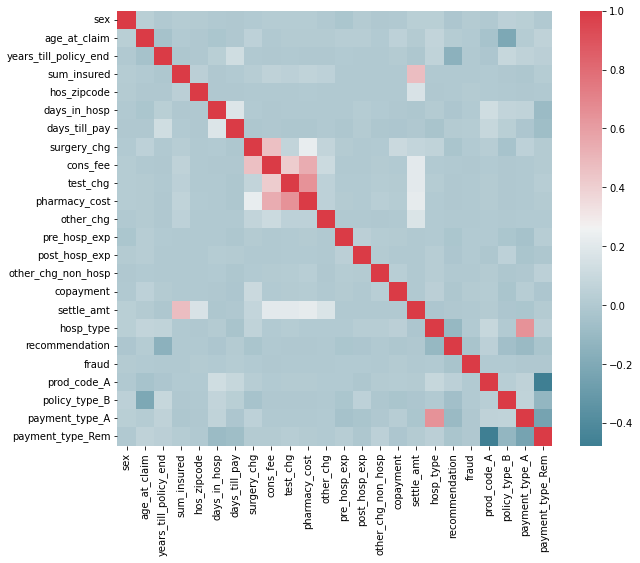

In [17]:
f, ax = plt.subplots(figsize=(10, 8))
corr = data_train.corr()
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=np.bool),
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            square=True, ax=ax)

In [ ]:
data_train.to_csv("data_train.csv")
data_test.to_csv("data_test.csv")
data_validation.to_csv("data_validation.csv")

In [ ]:
data_train.describe()

In [ ]:
data_validation.head()

In [18]:
data_train.head()

,sex,age_at_claim,years_till_policy_end,sum_insured,hos_zipcode,days_in_hosp,days_till_pay,surgery_chg,cons_fee,test_chg,...,other_chg_non_hosp,copayment,settle_amt,hosp_type,recommendation,fraud,prod_code_A,policy_type_B,payment_type_A,payment_type_Rem
40305,1,24.082630,0.219033,10000,0.679668,2.0,7.0,0.00,196.47000,424.95001,...,504.95999,0.0,1305,1,0,0.0,1,0,0,1
44937,0,40.077483,0.755662,7500,58.539890,5.0,36.0,0.00,431.23001,0.00000,...,0.00000,0.0,430,1,0,0.0,0,0,1,0
66953,0,54.369357,0.780303,5000,13.631011,0.0,12.0,0.00,26.25000,0.00000,...,17.77000,0.0,1700,0,0,0.0,1,0,0,0
40268,0,82.512303,0.585912,0,1.557638,36.0,23.0,1250.33,150.03999,4.50000,...,0.00000,0.0,1910,1,0,0.0,1,0,1,0
79475,1,5.374511,0.637932,10000,7.576993,2.0,4.0,0.00,0.00000,0.00000,...,0.00000,0.0,945,1,0,1.0,1,1,0,1


In [20]:
scaler = MinMaxScaler()
scaler.fit(data_train)
data_train_norm = scaler.transform(data_train)
data_train_norm = pd.DataFrame(data_train_norm, index=list(data_train.index), columns=list(data_train.columns))
#data_test_norm = scaler.transform(data_test)
#data_test_norm = pd.DataFrame(data_test_norm, index=list(data_train.index), columns=list(data_train.columns))
data_val_norm = scaler.transform(data_validation)
data_val_norm = pd.DataFrame(data_val_norm, index=list(data_validation.index), columns=list(data_train.columns))


#data_train_norm.to_csv("data_train_norm.csv")
#data_val_norm.to_csv("data_val_norm.csv")

In [22]:
data_train_norm.describe()

,sex,age_at_claim,years_till_policy_end,sum_insured,hos_zipcode,days_in_hosp,days_till_pay,surgery_chg,cons_fee,test_chg,...,other_chg_non_hosp,copayment,settle_amt,hosp_type,recommendation,fraud,prod_code_A,policy_type_B,payment_type_A,payment_type_Rem
count,64000.000000,64000.000000,64000.000000,64000.000000,6.400000e+04,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,...,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,0.531125,0.356970,0.708050,0.000070,4.864063e-05,0.042958,0.036064,0.001704,0.000289,0.000256,...,0.000189,0.000584,0.000324,0.506328,0.048352,0.217000,0.926828,0.154719,0.328437,0.108391
std,0.499034,0.178740,0.053504,0.004017,4.540113e-03,0.076124,0.046910,0.010762,0.007013,0.005792,...,0.006512,0.008238,0.005644,0.499964,0.171262,0.412206,0.260420,0.361639,0.469649,0.310876
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.242860,0.674324,0.000002,1.127136e-08,0.005272,0.007437,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000034,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,1.000000,0.346632,0.710473,0.000004,3.499181e-07,0.008787,0.019336,0.000000,0.000013,0.000000,...,0.000000,0.000000,0.000073,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.501386,0.743919,0.000009,1.165923e-06,0.050967,0.047100,0.000000,0.000165,0.000139,...,0.000000,0.000000,0.000140,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


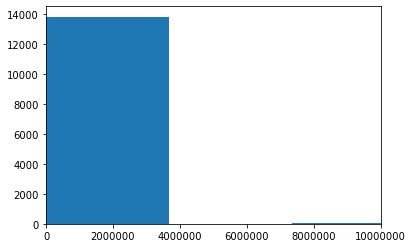

<Figure size 1152x1008 with 0 Axes>

In [47]:
fig, ax = plt.subplots()
ax.hist(data_train.sum_insured[data_train_norm.fraud==1], 10, histtype = 'bar')
ax.ticklabel_format(useOffset=False, style='plain')
ax.set_xlim(0, 10000000)
plt.figure(figsize=(16, 14))
plt.show()


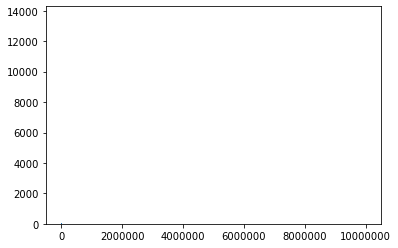

<Figure size 1152x1008 with 0 Axes>

In [56]:
fig, ax = plt.subplots()
ax.hist(data_train.sum_insured[data_train_norm.fraud==0], bins=np.linspace(0, 10000000, 50000), histtype = 'bar')
ax.ticklabel_format(useOffset=False, style='plain')
plt.figure(figsize=(16, 14))
plt.show()
